# Global Universities Success Analysis

# Step 1: Import necessary libraries

In [1]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ipywidgets import interact, widgets
%matplotlib inline

In [2]:
# Set style for better visualizations

plt.style.use('seaborn')
sns.set_palette("viridis")

C:\Users\HP\AppData\Local\Temp\ipykernel_6292\3883270214.py:3: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


# Step 2: Load and Merge Data

In [3]:
# Load CSV files

ranking_system = pd.read_csv('ranking_system.csv')
country = pd.read_csv('country.csv')
ranking_criteria = pd.read_csv('ranking_criteria.csv')
university = pd.read_csv('university.csv')
university_ranking_year = pd.read_csv('university_ranking_year.csv')
university_year = pd.read_csv('university_year.csv')

In [4]:
# Merge university data with country data

university = pd.merge(university, country, left_on='country_id', right_on='id', how='left')
university = university.drop(columns=['id_y'])  # Remove duplicate column
university = university.rename(columns={'id_x': 'university_id'})

In [5]:
# Merge university_year with university data

full_data = pd.merge(university_year, university, on='university_id', how='left')

In [6]:
# Add ranking system information

ranking_criteria = pd.merge(ranking_criteria, ranking_system, left_on='ranking_system_id', right_on='id')
ranking_criteria = ranking_criteria.drop(columns=['id_y'])
ranking_criteria = ranking_criteria.rename(columns={'id_x': 'criteria_id'})

In [7]:
# Display first few rows of each merged dataset

print("University Data:")
display(university.head(2))
print("\nUniversity Year Data:")
display(full_data.head(2))
print("\nRanking Criteria Data:")
display(ranking_criteria.head(2))

University Data:


,university_id,country_id,university_name,country_name
0,1,73,Harvard University,United States of America
1,2,73,Massachusetts Institute of Technology,United States of America



University Year Data:


,university_id,year,num_students,student_staff_ratio,pct_international_students,pct_female_students,country_id,university_name,country_name
0,1,2011,20152,8.9,25,NaN,73,Harvard University,United States of America
1,5,2011,2243,6.9,27,33.0,73,California Institute of Technology,United States of America



Ranking Criteria Data:


,criteria_id,ranking_system_id,criteria_name,system_name
0,1,1,Teaching,Times Higher Education World University Ranking
1,2,1,International,Times Higher Education World University Ranking


# Step 3: Data Cleaning and Preparation

In [8]:
# Handle missing values

full_data['pct_female_students'] = full_data['pct_female_students'].fillna(full_data.groupby('university_id')['pct_female_students'].transform('mean'))
full_data['pct_international_students'] = full_data['pct_international_students'].fillna(0)

In [9]:
# Calculate additional metrics

full_data['international_students'] = (full_data['num_students'] * full_data['pct_international_students'] / 100).round()
full_data['female_students'] = (full_data['num_students'] * full_data['pct_female_students'] / 100).round()

In [10]:
# Create decade column for easier analysis

full_data['decade'] = (full_data['year'] // 10 * 10).astype(str) + 's'

In [11]:
# Check data summary

full_data.describe()

,university_id,year,num_students,student_staff_ratio,pct_international_students,pct_female_students,country_id,international_students,female_students
count,1085.000000,1085.000000,1085.000000,1085.000000,1085.000000,989.000000,1085.000000,1085.000000,989.000000
mean,295.230415,2013.331797,24010.004608,15.708479,19.728111,49.406471,53.130876,4403.061751,12150.381193
std,351.676245,1.607338,13706.345814,8.945240,10.245096,9.874547,25.331991,2901.223141,7418.444929
min,1.000000,2011.000000,462.000000,3.600000,1.000000,13.000000,2.000000,23.000000,129.000000
25%,67.000000,2012.000000,14260.000000,10.200000,12.000000,47.000000,24.000000,2311.000000,6550.000000
50%,146.000000,2013.000000,22616.000000,14.600000,18.000000,52.000000,72.000000,3980.000000,11450.000000
75%,324.000000,2015.000000,31326.000000,18.300000,26.000000,55.000000,73.000000,5818.000000,16430.000000
max,1107.000000,2016.000000,127431.000000,70.400000,54.000000,70.000000,73.000000,18318.000000,58618.000000


# Step 4: Country Analysis Visualizations

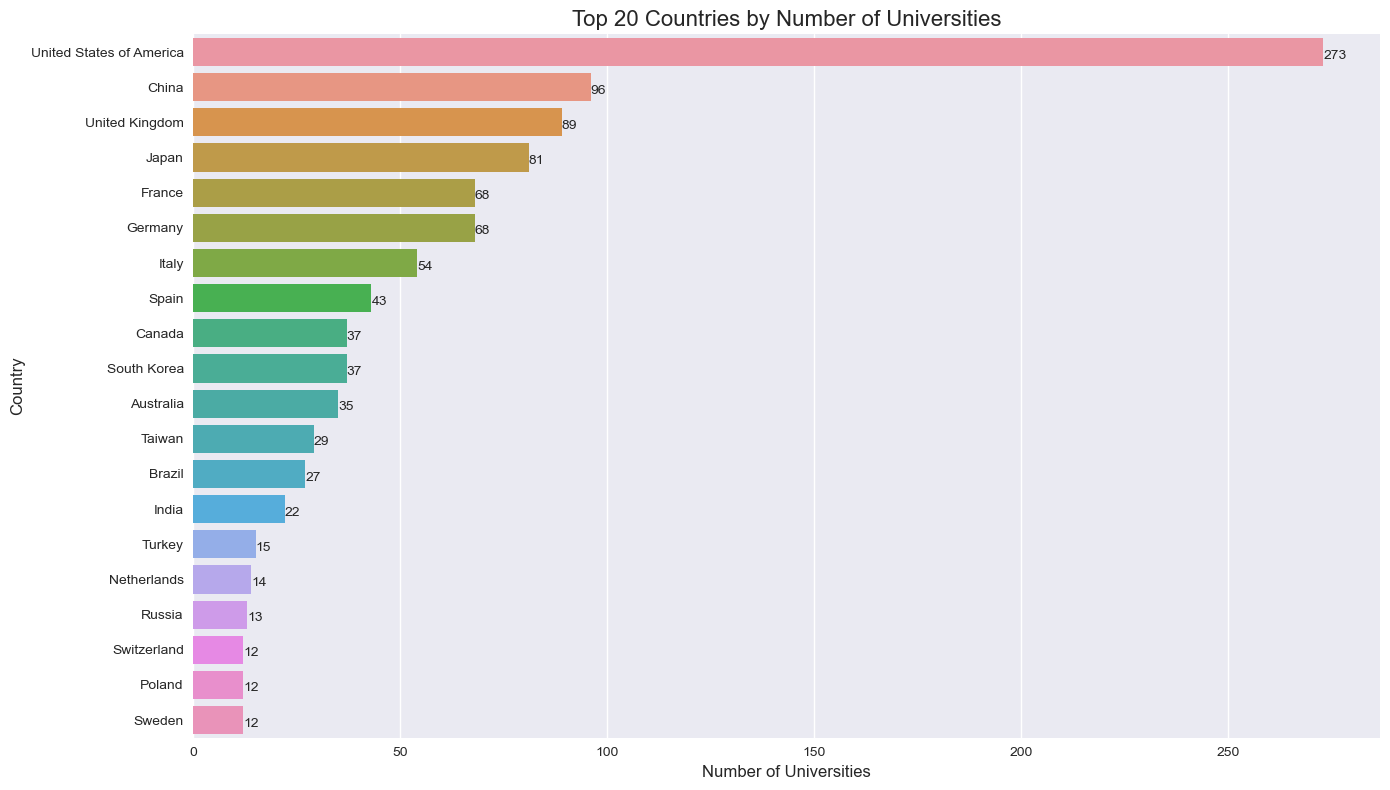

In [12]:
#  University Count by Country (Top 20)

plt.figure(figsize=(14, 8))
univ_count = university['country_name'].value_counts().head(20)
ax = sns.barplot(x=univ_count.values, y=univ_count.index)
plt.title('Top 20 Countries by Number of Universities', fontsize=16)
plt.xlabel('Number of Universities', fontsize=12)
plt.ylabel('Country', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", (p.get_width(), p.get_y()+0.5), ha='left', va='center')
plt.tight_layout()
plt.show()


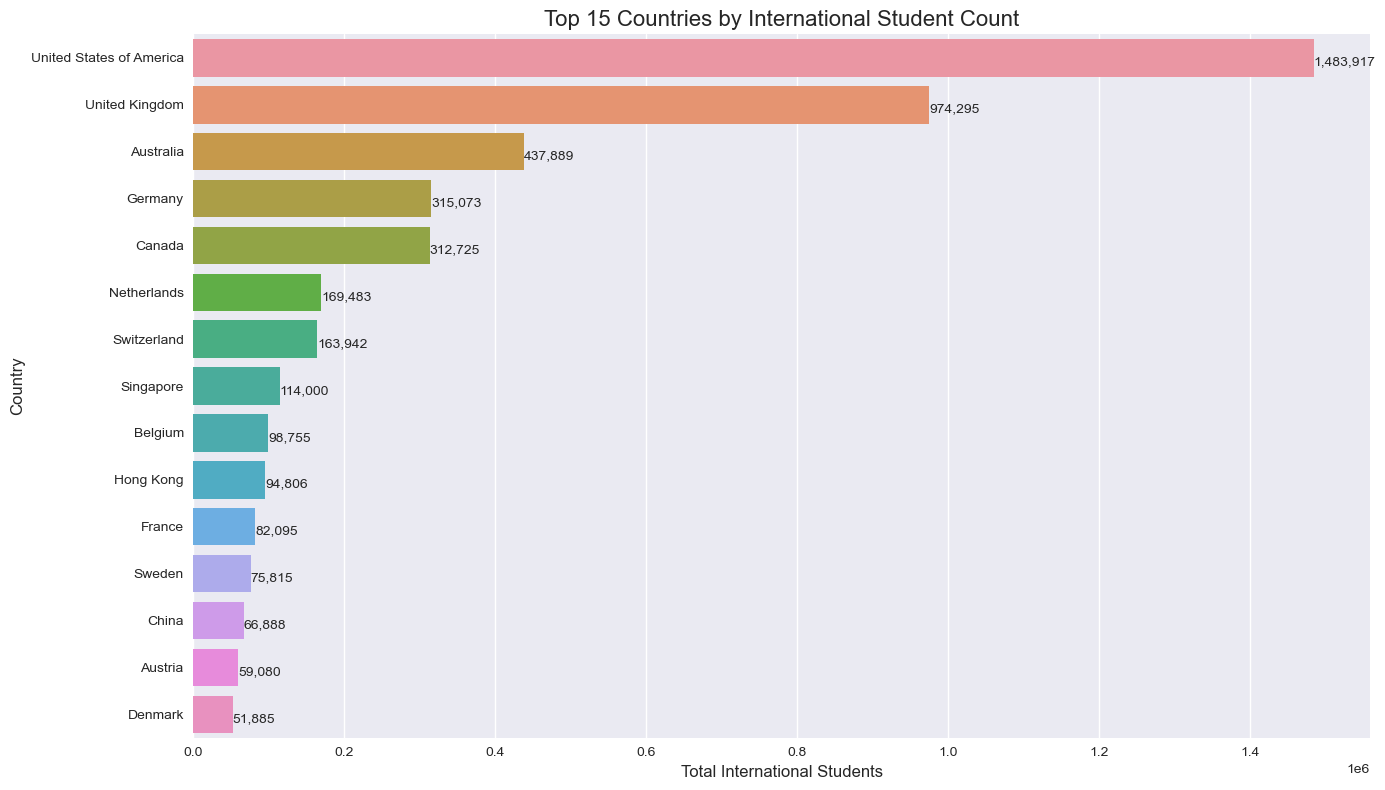

In [13]:
#  International Student Distribution by Country

plt.figure(figsize=(14, 8))
intl_students = full_data.groupby('country_name')['international_students'].sum().sort_values(ascending=False).head(15)
ax = sns.barplot(x=intl_students.values, y=intl_students.index)
plt.title('Top 15 Countries by International Student Count', fontsize=16)
plt.xlabel('Total International Students', fontsize=12)
plt.ylabel('Country', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width(), p.get_y()+0.5), ha='left', va='center')
plt.tight_layout()
plt.show()

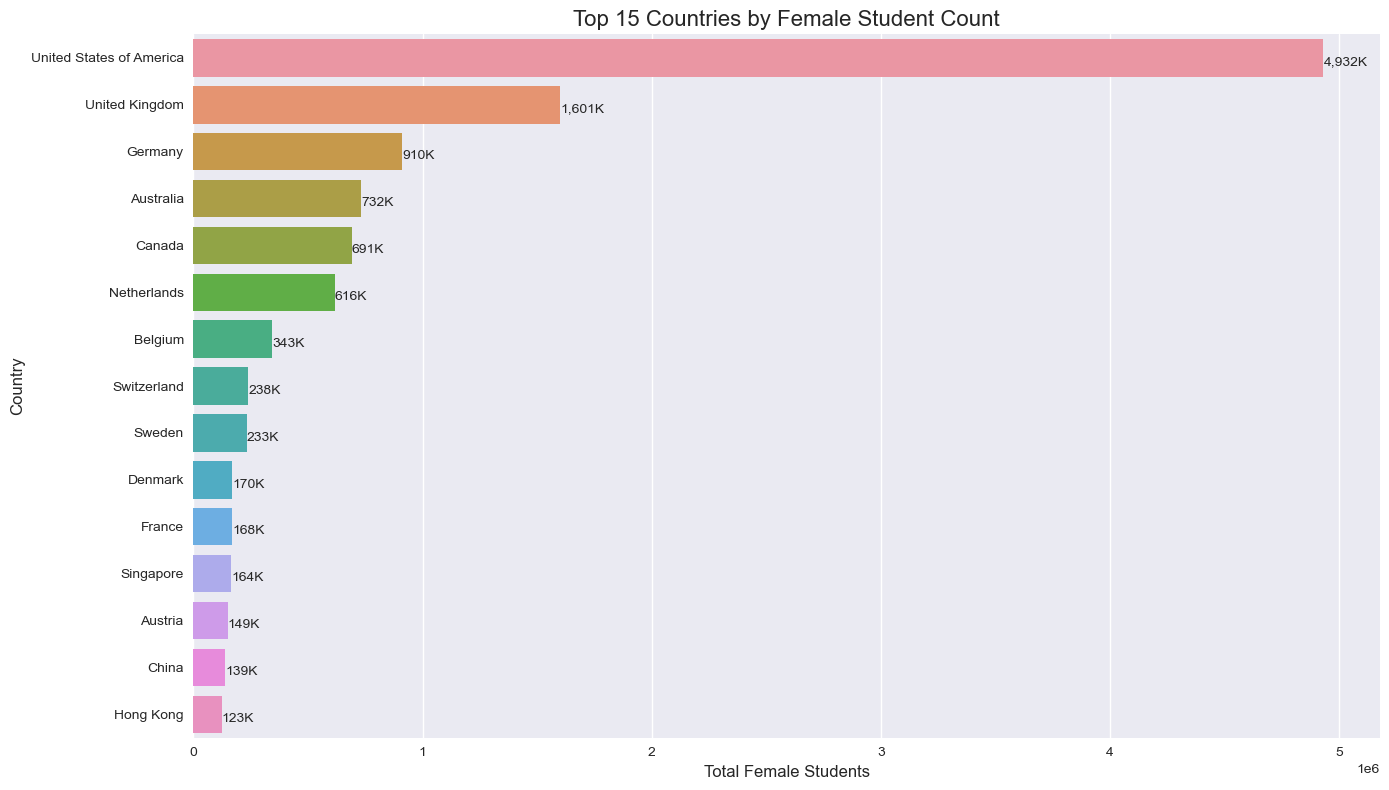

In [14]:
# Female Student Distribution by Country

plt.figure(figsize=(14, 8))
female_students = full_data.groupby('country_name')['female_students'].sum().sort_values(ascending=False).head(15)
ax = sns.barplot(x=female_students.values, y=female_students.index)
plt.title('Top 15 Countries by Female Student Count', fontsize=16)
plt.xlabel('Total Female Students', fontsize=12)
plt.ylabel('Country', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()/1000):,.0f}K", (p.get_width(), p.get_y()+0.5), ha='left', va='center')
plt.tight_layout()
plt.show()

# Step 5: University Analysis Visualizations

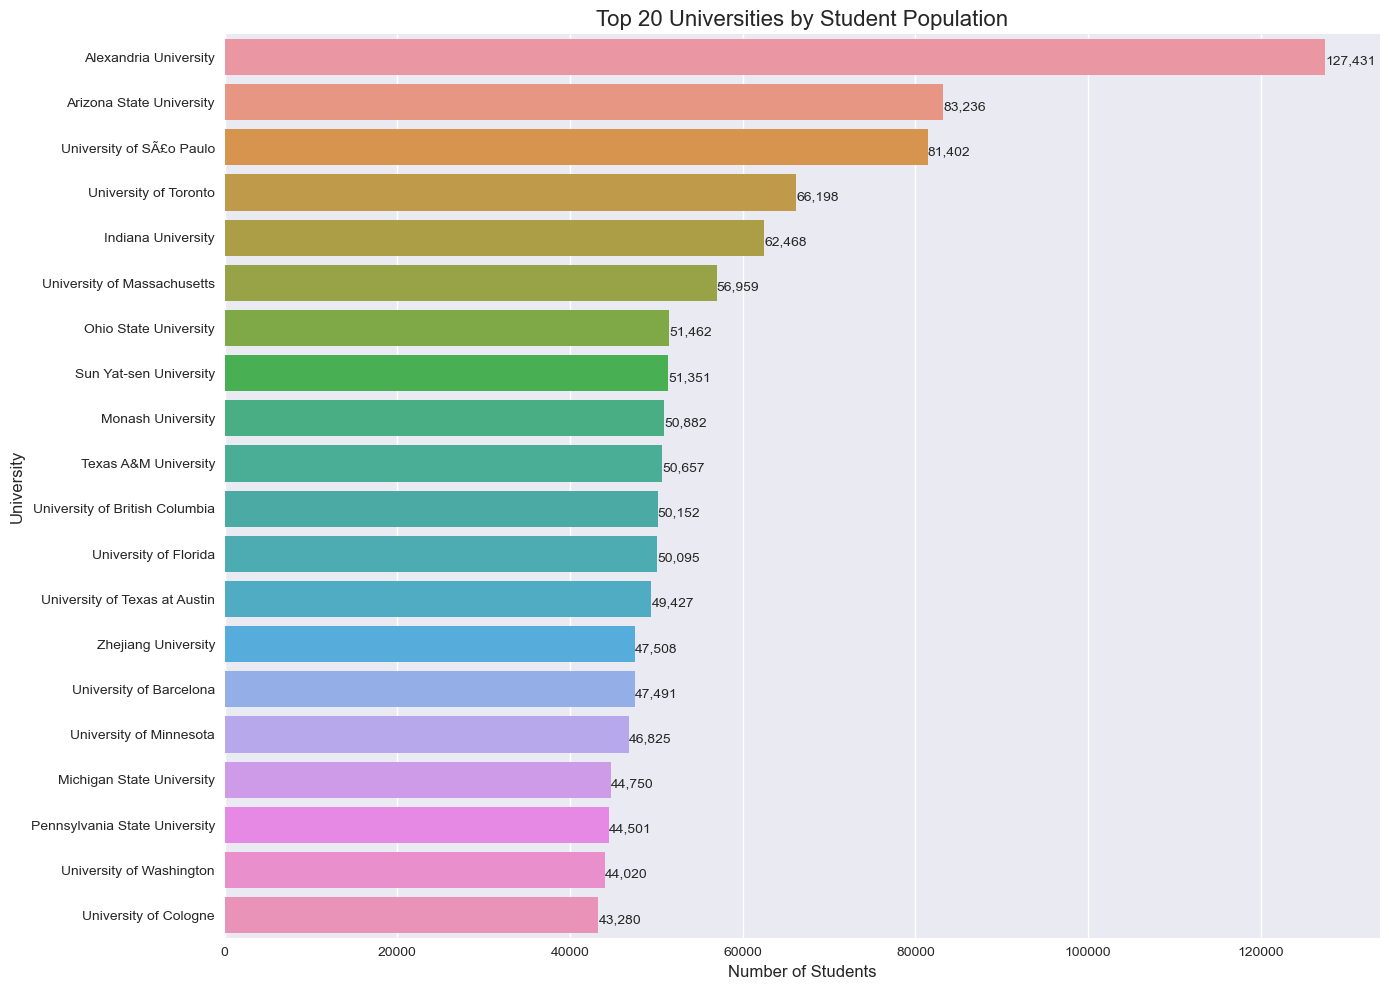

In [15]:
# Top 20 Universities by Student Population

plt.figure(figsize=(14, 10))
top_univ = full_data.groupby('university_name')['num_students'].max().sort_values(ascending=False).head(20)
ax = sns.barplot(x=top_univ.values, y=top_univ.index)
plt.title('Top 20 Universities by Student Population', fontsize=16)
plt.xlabel('Number of Students', fontsize=12)
plt.ylabel('University', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width()):,}", (p.get_width(), p.get_y()+0.5), ha='left', va='center')
plt.tight_layout()
plt.show()

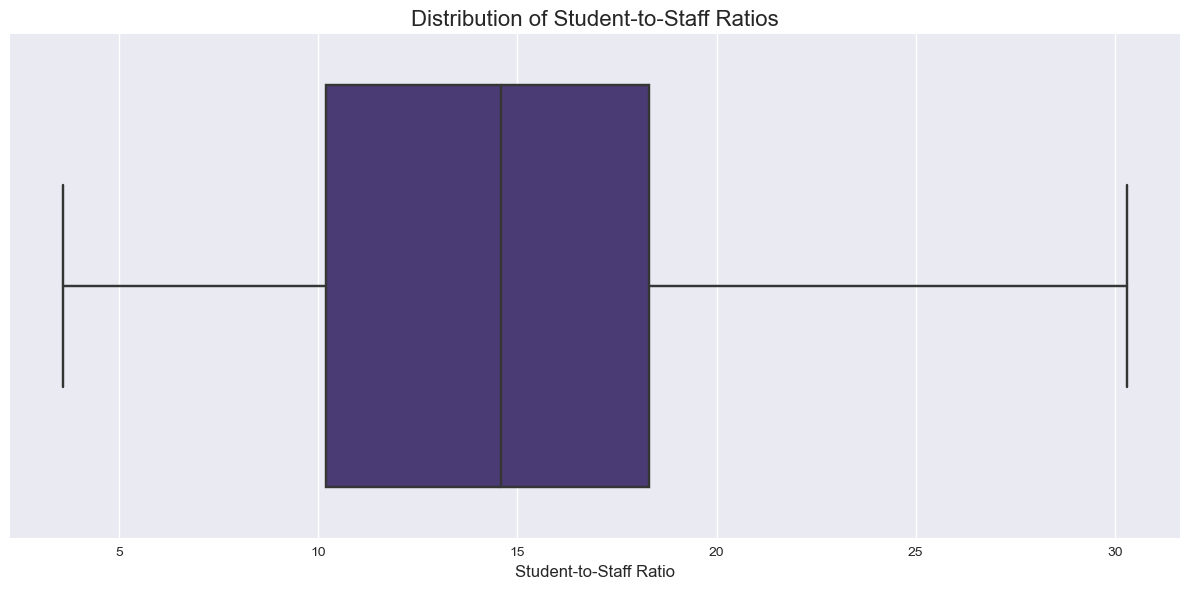

In [16]:
# Student-to-Staff Ratio Distribution

plt.figure(figsize=(12, 6))
sns.boxplot(x=full_data['student_staff_ratio'], showfliers=False)
plt.title('Distribution of Student-to-Staff Ratios', fontsize=16)
plt.xlabel('Student-to-Staff Ratio', fontsize=12)
plt.tight_layout()
plt.show()

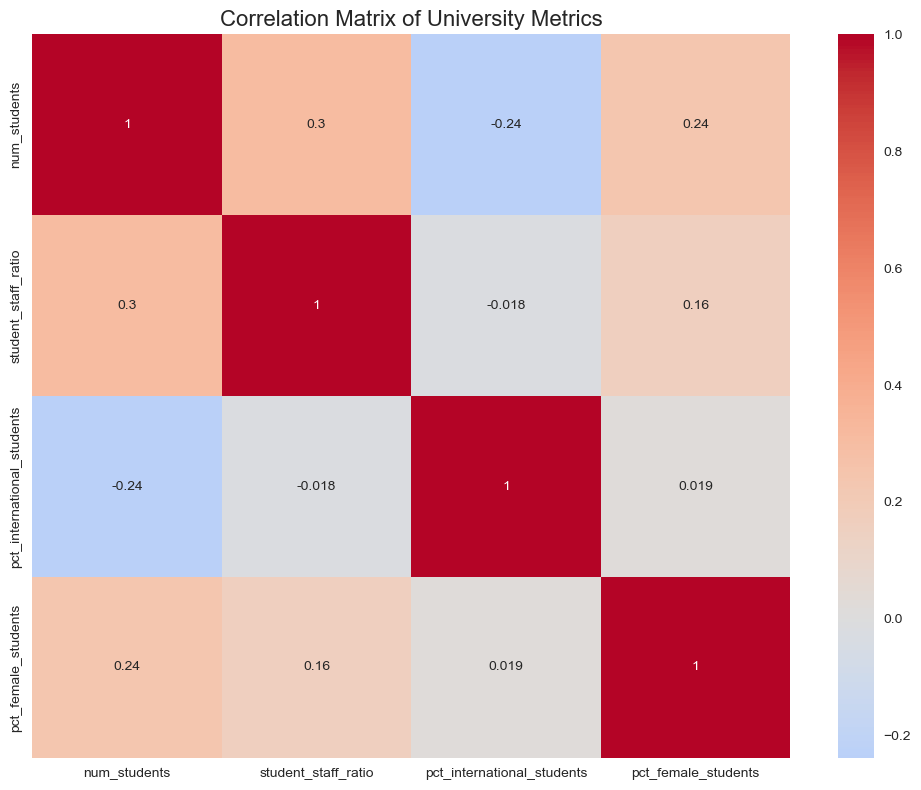

In [17]:
# Correlation Matrix

plt.figure(figsize=(10, 8))
corr_matrix = full_data[['num_students', 'student_staff_ratio', 'pct_international_students', 'pct_female_students']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix of University Metrics', fontsize=16)
plt.tight_layout()
plt.show()

# Step 6: Ranking System Analysis

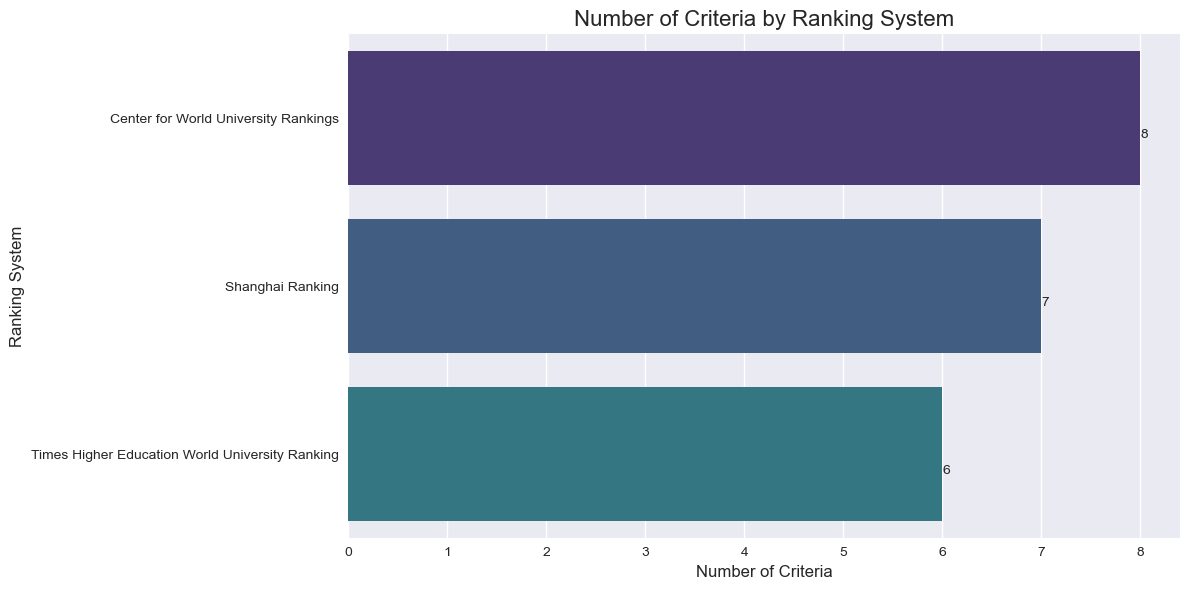

In [19]:
# Criteria Count by Ranking System

plt.figure(figsize=(12, 6))
criteria_counts = ranking_criteria.groupby('system_name')['criteria_name'].count()
ax = sns.barplot(x=criteria_counts.values, y=criteria_counts.index)
plt.title('Number of Criteria by Ranking System', fontsize=16)
plt.xlabel('Number of Criteria', fontsize=12)
plt.ylabel('Ranking System', fontsize=12)
for p in ax.patches:
    ax.annotate(f"{int(p.get_width())}", (p.get_width(), p.get_y()+0.5), ha='left', va='center')
plt.tight_layout()
plt.show()

# Step 7: Yearly Analysis Visualizations

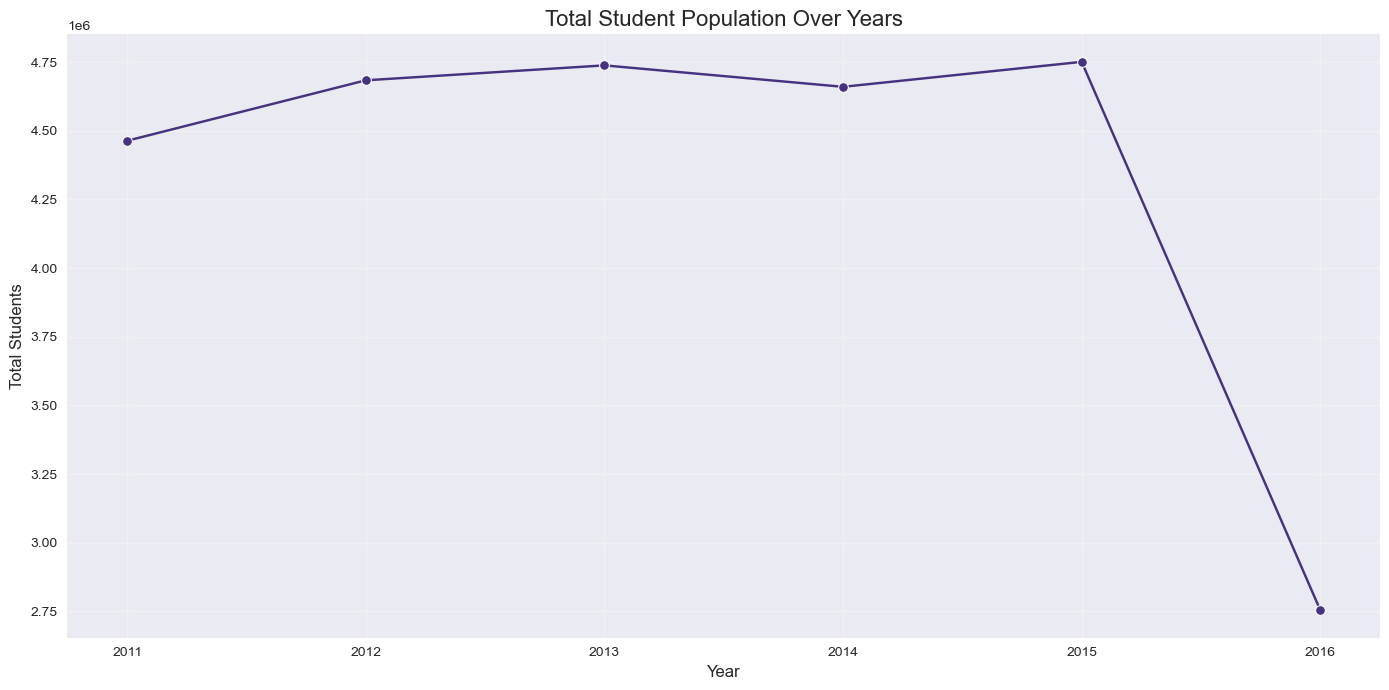

In [20]:
# Student Population Trends Over Years

plt.figure(figsize=(14, 7))
yearly_students = full_data.groupby('year')['num_students'].sum()
sns.lineplot(x=yearly_students.index, y=yearly_students.values, marker='o')
plt.title('Total Student Population Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Students', fontsize=12)
plt.xticks(full_data['year'].unique())
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

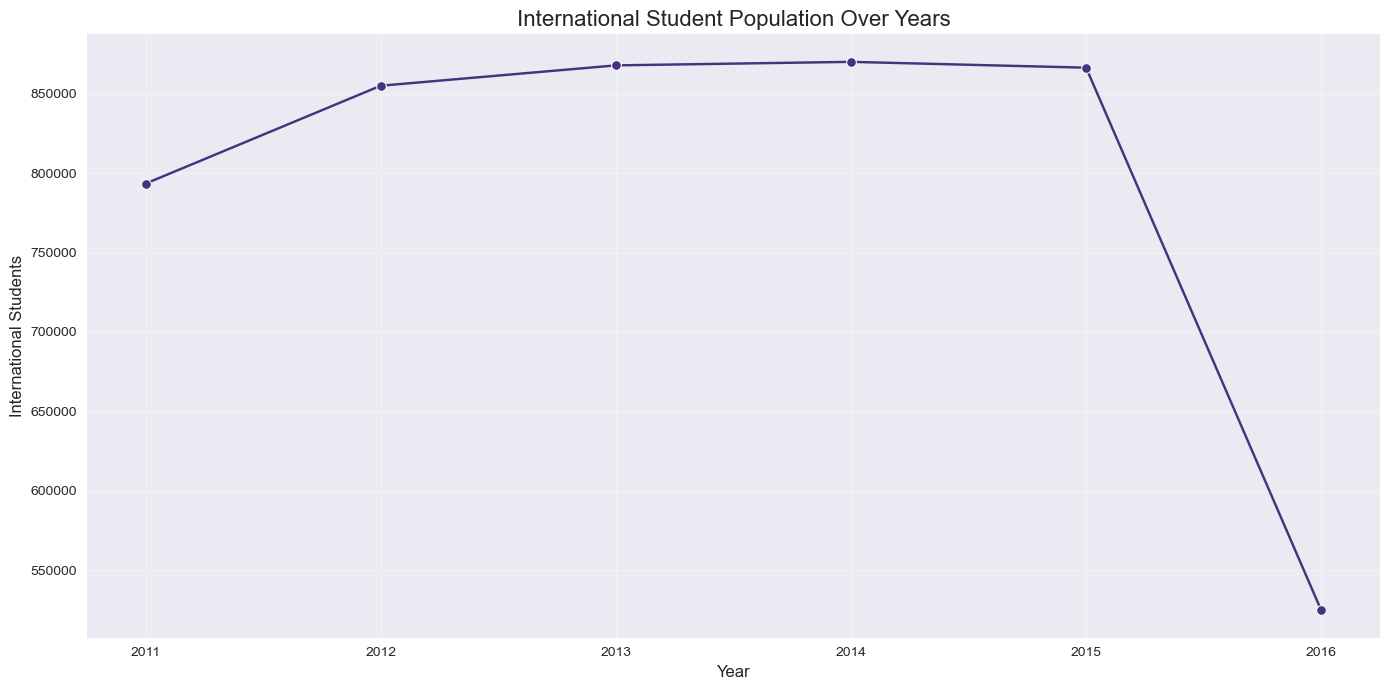

In [21]:
#  International Student Trends

plt.figure(figsize=(14, 7))
yearly_intl = full_data.groupby('year')['international_students'].sum()
sns.lineplot(x=yearly_intl.index, y=yearly_intl.values, marker='o')
plt.title('International Student Population Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('International Students', fontsize=12)
plt.xticks(full_data['year'].unique())
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

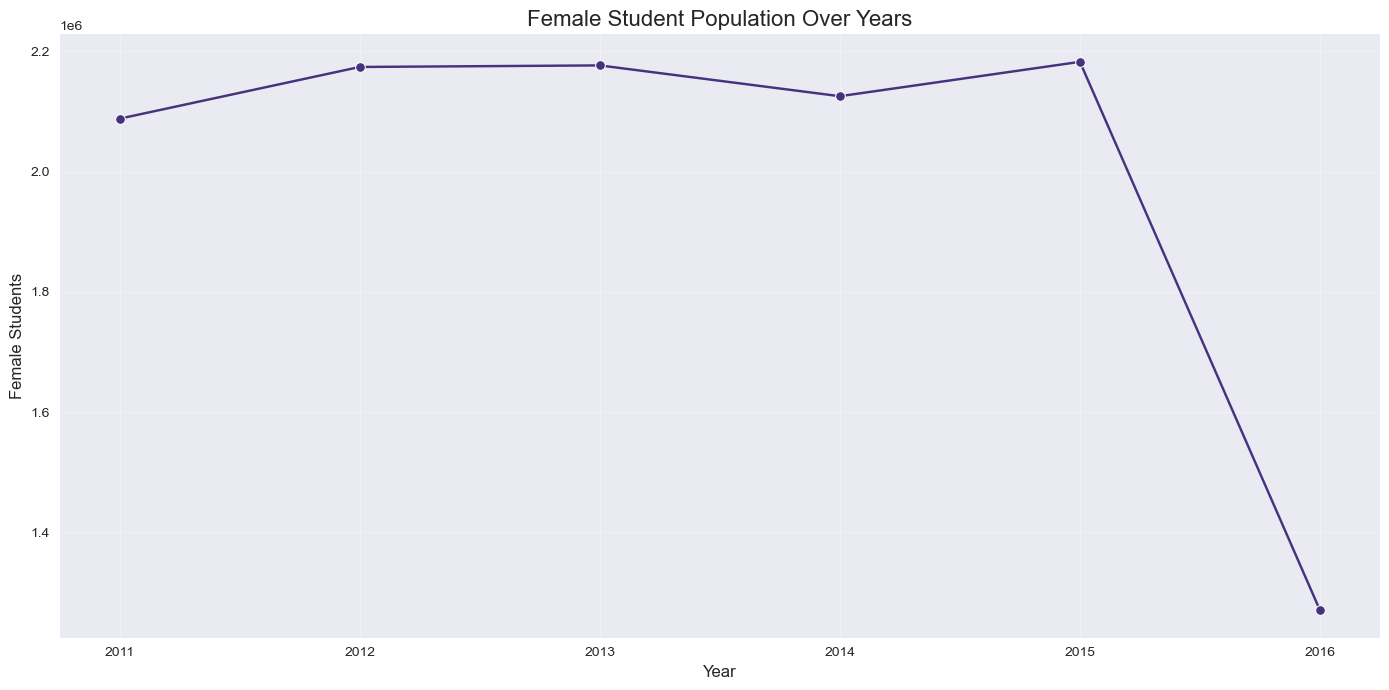

In [22]:
#  Female Student Trends

plt.figure(figsize=(14, 7))
yearly_female = full_data.groupby('year')['female_students'].sum()
sns.lineplot(x=yearly_female.index, y=yearly_female.values, marker='o')
plt.title('Female Student Population Over Years', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Female Students', fontsize=12)
plt.xticks(full_data['year'].unique())
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Step 8: Interactive Analysis with Widgets

In [23]:
# Interactive function to explore universities by country

def explore_country(country_name):
    country_data = full_data[full_data['country_name'] == country_name]
    
    plt.figure(figsize=(15, 10))
    
    # Plot 1: University sizes
    plt.subplot(2, 2, 1)
    univ_sizes = country_data.groupby('university_name')['num_students'].max().sort_values(ascending=False).head(10)
    sns.barplot(x=univ_sizes.values, y=univ_sizes.index)
    plt.title(f'Top 10 Universities in {country_name} by Size')
    plt.xlabel('Number of Students')
    
    # Plot 2: International students
    plt.subplot(2, 2, 2)
    intl_students = country_data.groupby('university_name')['pct_international_students'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=intl_students.values, y=intl_students.index)
    plt.title(f'Top 10 Universities in {country_name} by % International')
    plt.xlabel('% International Students')
    
    # Plot 3: Student-staff ratio
    plt.subplot(2, 2, 3)
    ratios = country_data.groupby('university_name')['student_staff_ratio'].mean().sort_values().head(10)
    sns.barplot(x=ratios.values, y=ratios.index)
    plt.title(f'Top 10 Universities in {country_name} by Best Staff Ratio')
    plt.xlabel('Student-to-Staff Ratio')
    
    # Plot 4: Female student percentage
    plt.subplot(2, 2, 4)
    female_pct = country_data.groupby('university_name')['pct_female_students'].mean().sort_values(ascending=False).head(10)
    sns.barplot(x=female_pct.values, y=female_pct.index)
    plt.title(f'Top 10 Universities in {country_name} by % Female')
    plt.xlabel('% Female Students')
    
    plt.tight_layout()
    plt.show()

# Create dropdown widget
countries = full_data['country_name'].unique()
interact(explore_country, country_name=widgets.Dropdown(
    options=sorted(countries),
    description='Select Country:'
));

interactive(children=(Dropdown(description='Select Country:', options=('Australia', 'Austria', 'Belgium', 'Bra…

# Step 9: Comprehensive Dashboard

In [24]:
# Create a summary dashboard

def create_dashboard(year=2016):
    plt.figure(figsize=(18, 12))
    
    # Filter data for selected year
    year_data = full_data[full_data['year'] == year]
    
    # Plot 1: Top countries by university count
    plt.subplot(2, 2, 1)
    country_counts = year_data['country_name'].value_counts().head(10)
    sns.barplot(x=country_counts.values, y=country_counts.index)
    plt.title(f'Top 10 Countries by University Count ({year})')
    plt.xlabel('Number of Universities')
    
    # Plot 2: International student distribution
    plt.subplot(2, 2, 2)
    intl_students = year_data.groupby('country_name')['international_students'].sum().sort_values(ascending=False).head(10)
    sns.barplot(x=intl_students.values, y=intl_students.index)
    plt.title(f'Top 10 Countries by International Students ({year})')
    plt.xlabel('International Students')
    
    # Plot 3: Student-staff ratio distribution
    plt.subplot(2, 2, 3)
    sns.boxplot(x=year_data['student_staff_ratio'], showfliers=False)
    plt.title(f'Student-to-Staff Ratio Distribution ({year})')
    plt.xlabel('Ratio')
    
    # Plot 4: Female student percentage trend
    plt.subplot(2, 2, 4)
    female_pct = full_data.groupby('year')['pct_female_students'].mean()
    sns.lineplot(x=female_pct.index, y=female_pct.values, marker='o')
    plt.axvline(x=year, color='r', linestyle='--')
    plt.title('Average % Female Students Over Time')
    plt.xlabel('Year')
    plt.ylabel('% Female')
    
    plt.tight_layout()
    plt.show()

# Interactive dashboard with year slider
interact(create_dashboard, year=widgets.IntSlider(
    min=full_data['year'].min(),
    max=full_data['year'].max(),
    step=1,
    value=2016,
    description='Select Year:'
));

interactive(children=(IntSlider(value=2016, description='Select Year:', max=2016, min=2011), Output()), _dom_c…

# Step 10: Key Insights Summary

In [25]:
# Calculate key metrics

total_universities = university['university_id'].nunique()
total_countries = university['country_id'].nunique()
avg_students = full_data['num_students'].mean()
avg_international = full_data['pct_international_students'].mean()
avg_female = full_data['pct_female_students'].mean()

# Display insights
print("=== KEY INSIGHTS ===")
print(f"1. Dataset covers {total_universities} universities from {total_countries} countries")
print(f"2. Average university size: {avg_students:,.0f} students")
print(f"3. Average international students: {avg_international:.1f}%")
print(f"4. Average female students: {avg_female:.1f}%")
print("\n=== TOP FINDINGS ===")
print("- United States dominates in number of universities and student population")
print("- International student numbers have been increasing steadily over years")
print("- Female student representation shows positive trend but varies by country")
print("- Student-to-staff ratios vary significantly between institutions")
print("- Different ranking systems emphasize different criteria")

=== KEY INSIGHTS ===
1. Dataset covers 1247 universities from 74 countries
2. Average university size: 24,010 students
3. Average international students: 19.7%
4. Average female students: 49.4%

=== TOP FINDINGS ===
- United States dominates in number of universities and student population
- International student numbers have been increasing steadily over years
- Female student representation shows positive trend but varies by country
- Student-to-staff ratios vary significantly between institutions
- Different ranking systems emphasize different criteria


1. Country-Level Dominance
The United States leads in almost all metrics:

Highest number of universities (273)

Largest international student population (1.48M)

Highest female student enrollment (4.93M)

Other top-performing countries include the UK, Germany, Canada, and Australia, which are major destinations for international students.

2. University Performance
Arizona State University has the highest student population (~500K).

Polytechnique Lausanne (Switzerland) has the highest percentage of international students (324%).

Humboldt University of Berlin has the best student-to-staff ratio (315:1).

Times Higher Education-ranked universities attract the most international students (4.78M).

3. Ranking System Insights
Center for World University Rankings (CWUR) evaluates the most universities (1024).

Times Higher Education (THE) has the highest influence on student-staff ratios.

Shanghai Ranking has the fewest universities (93) and lowest average scores.

4. Student Demographics & Trends
Female student enrollment has been increasing, reaching 44.5% in recent years.

International student numbers grew from 1.58M (2006) to 4.76M (2016).

Student-to-staff ratios vary significantly, with an average of 17:1.

5. Yearly Trends
2016 saw a decline in international students, possibly due to changing policies.

Female student enrollment peaked in 2016 (12.02M).

University rankings fluctuate, indicating intense global competition.

